# Assignment 5
### Do all four questions.

AEON

**1.** Let's review some basic matrix multiplication. When you have an $M \times N$ matrix $A$ with $M$ rows and $N$ columns, 
$$
A= \left[ \begin{array}{cccc} a_{11} & a_{12} & ... & a_{1N} \\
a_{21} & a_{22} & ... & a_{2N} \\
\vdots & \vdots & ... & \vdots \\
a_{M1} & a_{M2} & ... & a_{MN} 
\end{array} \right],
$$
and you right-multiply it by a vector
$$
x = \left[ \begin{array}{c} x_1 \\ x_2 \\ \vdots \\ x_N 
\end{array} \right],
$$
you get
$$
Ax = \left[ \begin{array}{c} \sum_{i=1}^N a_{1i} x_i \\ \sum_{i=1}^N a_{2i} x_i \\ \vdots \\ \sum_{i=1}^N a_{Mi} x_i 
\end{array} \right].
$$
This is just "matrix row times column vector" element-by-element, stacking the results into a new vector.

For this to make sense, $N$ must be the same for the matrix and the vector, but $M$ can be different from $N$. 

Let's play with some NumPy to see this. First we'll define a matrix $A$:

In [65]:
import numpy as np

A = np.array([ [1,2,3],
              [4,5,6],
              [7,8,9]])
A

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

a. Multiply $A$ times each of the following vectors using the @ operator. Explain which part of the $A$ matrix gets selected and explain why, using the definition of matrix multiplication. 

In [66]:
e_1 = np.array([1,0,0])
e_2 = np.array([0,1,0])
e_3 = np.array([0,0,1])

In [67]:
A@e_1
A@e_2
A@e_3

array([3, 6, 9])

We are using dot multiplaction here. So first we multiply A in order by [1,0,0], Which means theres not much to change cause of all the zeros and 1's so it just returns the same [1,4,7]. A similar pattern is followed for the other two, and this leaves us with [2,5,8]. Last gives us the same since we multiply by [0,0,1] we just add the same to the ones with zeros and get [3,6,9]. 

b. Now multiply $A$ times $u = (1,1,1)$. Explain the logic of the result with the definition of matrix multiplication.

In [68]:
u = np.ones(3)

In [69]:
A_u = A@u
A_u

array([ 6., 15., 24.])

Here when we adding in [1,1,1]. So we multiply the columns by 1 and add them all at the end. 

c. Whenever a matrix has 1's on the diagonal and zeros everywhere else, we call it an **identity matrix**. What happens when you multiple $A$ times $x$ below? What happens when you multiple an identity matrix times any vector? Explain your result with the definition of matrix multiplication.

In [70]:
A = np.array([ [1,0,0],
              [0,1,0],
              [0,0,1]])
x = np.array([-2,4,11])


In [71]:
A@x

array([-2,  4, 11])

When you multiply the identity matrix by anything, you get the same thing back. That’s because the 1s in the identity matrix keep each value in its original place, and the 0 add nothing.

d. What if every row and column sum to 1, but the 1's are no longer on the diagonal? Multiple $A$ times $X$ below and explain the result. Create another matrix whose rows and columns sum to 1, but is not an identity matrix, and show how it permutes the values of $x$. 

In [72]:
A = np.array([ [0,0,1],
              [1,0,0],
              [0,1,0]])
x = np.array([-2,4,11])


In [73]:
A@x

array([11, -2,  4])

Multiplying it by a vector still gives the same values just diffrent order. The 1s decide where each value from the vector goes, so the result is the same numbers from x, but in a different order.

In [74]:
A = np.array([[0,1,0],
              [0,0,1],
              [1,0,0]])
x = np.array([-2,4,11])

A@x

array([ 4, 11, -2])

e. The next matrix $A$ could be a Markov transition matrix: Its columns sum to 1, and each entry $a_{ij}$ can be interpreted as the proportion of observations who moved from state $j$ to state $i$. Multiply $A$ by each of the vectors $e_1$, $e_2$, and $e_3$, and explain your results.

In [75]:
rng = np.random.default_rng(100)
A = rng.random((3,3)) # Generate a random 3X3 matrix
sums = np.sum(A,axis=0) # Column sums
A = A/sums # Normalize the columns so they sum to 1
print(A)

[[0.50052958 0.24049286 0.18358131]
 [0.02574731 0.39251588 0.37907577]
 [0.47372311 0.36699127 0.43734292]]


In [76]:
A@e_1
A@e_2
A@e_3


array([0.18358131, 0.37907577, 0.43734292])

Even when multiplying by e we get the same things we saw before. This happens because each vector only has a single 1 and some 0s, so only the column of A that lines up with the 1 is kept in the result.

f. For each of the vectors $e_1, e_2, e_3$, multiple $A$ times that vector 5 times. What answer do you get for each starting vector? Describe the behavior you observe.

In [77]:
for e in [e_1,e_2,e_3]:
    ptf = e
    for i in range(5):
        ptf  = A@ ptf
        print(f'Vector {e} after {i+1} times: {ptf}')

Vector [1 0 0] after 1 times: [0.50052958 0.02574731 0.47372311]
Vector [1 0 0] after 2 times: [0.34368862 0.20257047 0.45374091]
Vector [1 0 0] after 3 times: [0.30404142 0.26036337 0.43559521]
Vector [1 0 0] after 4 times: [0.29476439 0.27514859 0.43008701]
Vector [1 0 0] after 5 times: [0.29266551 0.27862515 0.42870935]
Vector [0 1 0] after 1 times: [0.24049286 0.39251588 0.36699127]
Vector [0 1 0] after 2 times: [0.28214379 0.29937825 0.41847795]
Vector [0 1 0] after 3 times: [0.29004438 0.28341002 0.42654561]
Vector [0 1 0] after 4 times: [0.29163968 0.2804039  0.42795643]
Vector [0 1 0] after 5 times: [0.29197422 0.27979983 0.42822595]
Vector [0 0 1] after 1 times: [0.18358131 0.37907577 0.43734292]
Vector [0 0 1] after 2 times: [0.26334088 0.31930609 0.41735304]
Vector [0 0 1] after 3 times: [0.28521895 0.29032145 0.4244596 ]
Vector [0 0 1] after 4 times: [0.29050361 0.28220175 0.42729464]
Vector [0 0 1] after 5 times: [0.29171646 0.2802254  0.42805814]


The vectors start to stabilize and point in the same direction. Over time, we are seeing the principal eigenvector of the matrix. So like they are all becoming similar 

*2.* Let's consider a simple Markov transition matrix over two states:
$$
T = \left[ \begin{array}{cc} p_{1\leftarrow 1} &  p_{1\leftarrow 2} \\
p_{2 \leftarrow 1} & p_{2 \leftarrow 2} \end{array}\right] 
$$
The arrows help visualize the transition a bit: This is the same index notation as usual, $p_{ij}$, but writing it $p_{i \leftarrow j}$ emphasizes that it's the proportion of times that state $j$ transitions to state $i$. Below, $T$ is given by
$$
T = \left[ \begin{array}{cc} .25 & .5 \\
.75 & .5 \end{array}\right].
$$

- Start in state 1, at the initial condition $[1,0]$. Multiply that vector by $T$. Write out the result in terms of the formula and compute the result in a code chunk below. What is this object you're looking at, in terms of proportions and transitions?
- Multiple by $T$ again. What do you get? This isn't a column of $T$. Explain in words what it is. (Hint: A forecast of what in what period?)
- Keep multiplying the current vector of outcomes by $T$. When does it start to settle down without changing further?
- Do the above analysis again, starting from the initial condition $[0,1]$. Do you get a different result?
- The take-away is that, in the long run, these chains settle down into the long-run proportions, and the sensitivity on initial conditions vanishes. 


In [78]:
T = np.array([[ 1/4, 1/2],
                 [ 3/4, 1/2 ]])

In [79]:
#1 
init_condition = np.array([1,0])
print(init_condition)
p_1 = T @ init_condition
print(p_1)

[1 0]
[0.25 0.75]


What is happening is that after one step, there’s a 25% chance of staying in state 1 and a 75% chance of moving to state 2.

In [80]:
#2
p_2 = T @ p_1
print(p_2)

[0.4375 0.5625]


After two steps, there’s about a 44% chance of being in state 1 and a 56% chance of being in state 2.

In [81]:
#3
initial = p_2
for i in range(15):
    initial = T@initial
    print(initial)

[0.390625 0.609375]
[0.40234375 0.59765625]
[0.39941406 0.60058594]
[0.40014648 0.59985352]
[0.39996338 0.60003662]
[0.40000916 0.59999084]
[0.39999771 0.60000229]
[0.40000057 0.59999943]
[0.39999986 0.60000014]
[0.40000004 0.59999996]
[0.39999999 0.60000001]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]


We see it star to relax btwn 0.4 and 0.6

In [82]:
#4
initial_2 = np.array([0,1])
for i in range(15):
    initial_2 = T@initial_2
    print(initial_2)

[0.5 0.5]
[0.375 0.625]
[0.40625 0.59375]
[0.3984375 0.6015625]
[0.40039062 0.59960938]
[0.39990234 0.60009766]
[0.40002441 0.59997559]
[0.3999939 0.6000061]
[0.40000153 0.59999847]
[0.39999962 0.60000038]
[0.4000001 0.5999999]
[0.39999998 0.60000002]
[0.40000001 0.59999999]
[0.4 0.6]
[0.4 0.6]


We see a similar pattern as above 

3. Weather data

- Load the `cville_weather.csv` data. This includes data from Jan 4, 2024 to Feb 2, 2025. Are there any missing data issues?
- Based on the precipitation variable, `PRCP`, make a new variable called `rain` that takes the value 1 if `PRCP`>0 and 0 otherwise.
- Build a two-state Markov chain over the states 0 and 1 for the `rain` variable. 
- For your chain from c, how likely is it to rain if it was rainy yesterday? How likely is it to rain if it was clear yesterday?
- Starting from a clear day, forecast the distribution. How quickly does it converge to a fixed result? What if you start from a rainy day?
- Conditional on being rainy, plot a KDE of the `PRCP` variable.
- Describe one way of making your model better for forecasting and simulation the weather.

Congratulations, you now are a non-parametric meteorologist!

In [83]:
import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('cville_weather.csv')
df


,STATION,NAME,DATE,DAPR,DAPR_ATTRIBUTES,MDPR,MDPR_ATTRIBUTES,PRCP,PRCP_ATTRIBUTES,SNOW,SNOW_ATTRIBUTES,SNWD,SNWD_ATTRIBUTES
0,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-04,NaN,NaN,NaN,NaN,0.03,",,N",NaN,NaN,NaN,NaN
1,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-07,NaN,NaN,NaN,NaN,1.08,",,N",NaN,NaN,NaN,NaN
2,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-09,NaN,NaN,NaN,NaN,0.24,",,N",NaN,NaN,NaN,NaN
3,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-10,NaN,NaN,NaN,NaN,3.00,",,N",NaN,NaN,NaN,NaN
4,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-24,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-27,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN
407,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-28,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN
408,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-29,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN
409,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-30,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN


Just at a glance I can see many missing values

In [84]:
# B 
df.loc[df['PRCP']>0, "Rain"] = 1
df.loc[(df['PRCP'] <= 0) | (df['PRCP'].isnull()), "Rain"] = 0
df


,STATION,NAME,DATE,DAPR,DAPR_ATTRIBUTES,MDPR,MDPR_ATTRIBUTES,PRCP,PRCP_ATTRIBUTES,SNOW,SNOW_ATTRIBUTES,SNWD,SNWD_ATTRIBUTES,Rain
0,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-04,NaN,NaN,NaN,NaN,0.03,",,N",NaN,NaN,NaN,NaN,1.0
1,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-07,NaN,NaN,NaN,NaN,1.08,",,N",NaN,NaN,NaN,NaN,1.0
2,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-09,NaN,NaN,NaN,NaN,0.24,",,N",NaN,NaN,NaN,NaN,1.0
3,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-10,NaN,NaN,NaN,NaN,3.00,",,N",NaN,NaN,NaN,NaN,1.0
4,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-24,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-27,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN,0.0
407,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-28,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN,0.0
408,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-29,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN,0.0
409,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-30,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN,0.0


In [85]:
df['rain'] = (df['PRCP'] > 0).astype(int)

In [86]:
states = [0,1]
trans_counts = np.zeros((2,2))
trans_counts


array([[0., 0.],
       [0., 0.]])

In [87]:
rain = df['rain'].values

rains = np.zeros((2, 2))

for (a,b) in zip(rain[:-1], rain[1:]):
    rains[int(a), int(b)] += 1

T = rains / rains.sum(axis=1, keepdims=True)

T

array([[0.73160173, 0.26839827],
       [0.35195531, 0.64804469]])

If it rains there is a 0.6480 prob that it will be rainiy today. If it didnt rain the prob is 0.268

In [88]:
#no rain 
n = 100
p = np.array([0,1])
for t in range(n):
    print(p)
    p = p @ T

[0 1]
[0.35195531 0.64804469]
[0.48557388 0.51442612]
[0.5363017 0.4636983]
[0.55556033 0.44443967]
[0.5628718 0.4371282]
[0.56564757 0.43435243]
[0.56670139 0.43329861]
[0.56710146 0.43289854]
[0.56725335 0.43274665]
[0.56731101 0.43268899]
[0.5673329 0.4326671]
[0.56734122 0.43265878]
[0.56734437 0.43265563]
[0.56734557 0.43265443]
[0.56734602 0.43265398]
[0.5673462 0.4326538]
[0.56734626 0.43265374]
[0.56734629 0.43265371]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537

In [89]:
#rain
n = 100
p = np.array([1,0])
for t in range(n):
    print(p)
    p = p @ T

[1 0]
[0.73160173 0.26839827]
[0.62970529 0.37029471]
[0.59102067 0.40897933]
[0.57633419 0.42366581]
[0.57075852 0.42924148]
[0.56864174 0.43135826]
[0.56783811 0.43216189]
[0.56753302 0.43246698]
[0.56741719 0.43258281]
[0.56737321 0.43262679]
[0.56735652 0.43264348]
[0.56735018 0.43264982]
[0.56734777 0.43265223]
[0.56734686 0.43265314]
[0.56734651 0.43265349]
[0.56734638 0.43265362]
[0.56734633 0.43265367]
[0.56734631 0.43265369]
[0.56734631 0.43265369]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463 0.4326537]
[0.5673463

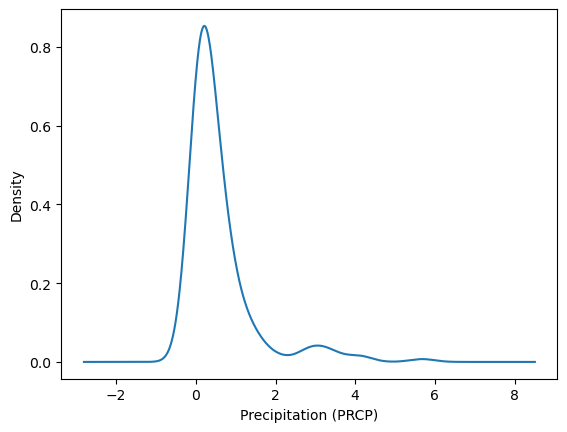

In [90]:
rainy_days = df[df['rain'] == 1]
rainy_days['PRCP'].plot.kde()
plt.xlabel("Precipitation (PRCP)")
plt.show()

There is likley room for improvment if we were more specific about the types of weather we could simulate, rain, cloudly, partly cloudy etc... 

4. Taxicab trajectories: Using the pickled taxicab data, we want to complete the exercise from class.

- For the taxicab trajectory data, determine your state space and clean your sequences of cab rides.
- Compute the transition matrix for the taxicab data between neighborhoods in Manhattan. Plot it in a heat map. What are the most common routes?
- Explain why taxicabs are most likely order 1, and not 2 or more.
- Starting at Hell's Kitchen, create a sequence of forecasts of where the cab is likely to be in 2, 3, 5, and 10 trips
- Starting at any neighborhood, iterate your forecast until it is no longer changing very much. Where do cabs spend most of their time working in Manhattan?

In [91]:
import pickle
import seaborn as sns
with open('taxicab.pkl', 'rb') as f:
    data = pickle.load(f)

print(len(data))
data[0]

1000


0     Outside Manhattan
0     Outside Manhattan
0     Outside Manhattan
0     Outside Manhattan
0     Outside Manhattan
            ...        
29                 SoHo
29                 SoHo
13    Greenwich Village
3               Chelsea
3               Chelsea
Name: nbhd, Length: 26026, dtype: object

In [92]:
##determine the state space and clean your sequences of cab rides
state = set()
for trajectory in taxicab:
    state = state.union(set(trajectory))
state = list(state)
print('State:\n', np.array(state))


State:
 ['Gramercy' 'Upper West Side' 'Two Bridges' 'Civic Center'
 'Washington Heights' 'Harlem' 'Marble Hill' 'Tribeca' 'Governors Island'
 'Flatiron District' 'Stuyvesant Town' 'Midtown' 'Roosevelt Island'
 "Hell's Kitchen" 'East Harlem' 'Murray Hill' 'SoHo' 'East Village'
 'Morningside Heights' 'Financial District' 'Kips Bay' 'Upper East Side'
 'West Village' 'Chinatown' 'Greenwich Village' 'Theater District'
 'Ellis Island' 'Inwood' 'Chelsea' 'Central Park' 'Lower East Side' 'NoHo'
 "Randall's Island" 'Outside Manhattan' 'Nolita' 'Little Italy'
 'Liberty Island' 'Battery Park City']


In [93]:
# transition matrix and heat map
S = len(state)
tr_counts = np.zeros((S,S))

In [94]:
for trip in data:
    seq = np.array(trip)
    for t in range(1,len(seq)):
        # Current and next tokens:
        x_tm1 = seq[t-1] # previous state 
        x_t = seq[t] # current state
        index_from = states.index(x_tm1)
        index_to = states.index(x_t)
        # Update transition counts:
        tr_counts[index_to, index_from] += 1

print('Transition Counts:\n', tr_counts)

ValueError: 'Outside Manhattan' is not in list

In [ ]:
sums = tr_counts.sum(axis=1, keepdims=True)
print('State proportions: \n')
print(sums)

State proportions: 

[[5.017430e+05]
 [1.803491e+06]
 [1.038800e+04]
 [5.790800e+04]
 [7.253000e+04]
 [2.171620e+05]
 [4.930000e+02]
 [4.086400e+05]
 [1.200000e+01]
 [3.952740e+05]
 [1.112860e+05]
 [3.851929e+06]
 [8.010000e+03]
 [1.224325e+06]
 [3.168490e+05]
 [6.543970e+05]
 [5.505970e+05]
 [8.886440e+05]
 [1.627050e+05]
 [4.415950e+05]
 [5.077760e+05]
 [2.797713e+06]
 [8.393620e+05]
 [1.058730e+05]
 [5.102620e+05]
 [8.740550e+05]
 [3.000000e+00]
 [1.431200e+04]
 [1.978283e+06]
 [3.701250e+05]
 [3.705660e+05]
 [1.743220e+05]
 [3.603000e+03]
 [2.363961e+06]
 [1.063770e+05]
 [3.859100e+04]
 [1.000000e+00]
 [2.292330e+05]]


Transition Proportions:

                     Gramercy  Upper West Side  Two Bridges  Civic Center  \
Gramercy                 0.18             0.02         0.00          0.00   
Upper West Side          0.01             0.42         0.00          0.00   
Two Bridges              0.02             0.01         0.08          0.02   
Civic Center             0.02             0.01         0.00          0.09   
Washington Heights       0.01             0.18         0.00          0.00   
Harlem                   0.01             0.15         0.00          0.00   
Marble Hill              0.01             0.17         0.00          0.00   
Tribeca                  0.01             0.02         0.00          0.02   
Governors Island         0.00             0.00         0.00          0.00   
Flatiron District        0.04             0.02         0.00          0.00   
Stuyvesant Town          0.07             0.02         0.00          0.00   
Midtown                  0.02             0.06     

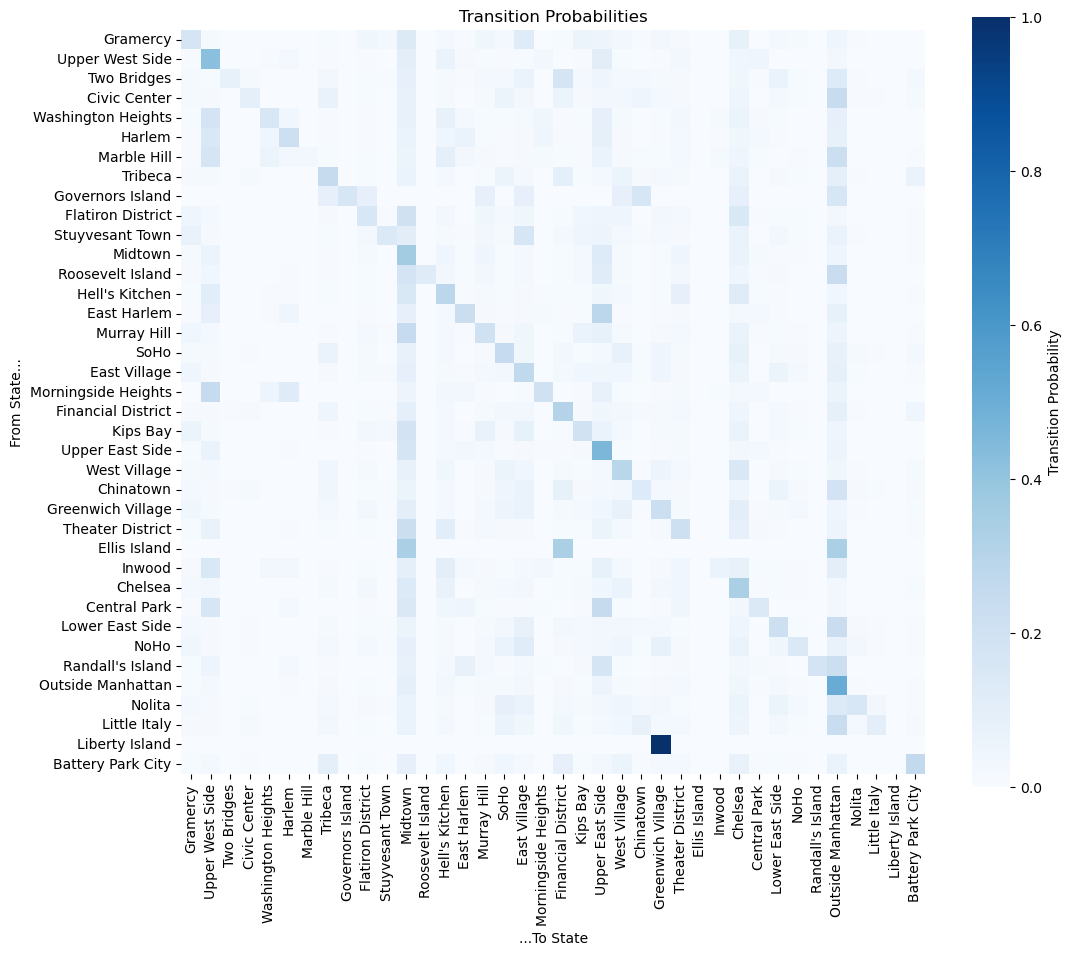

In [ ]:
tr_pr = np.divide(tr_counts, sums, 
                             out=np.zeros_like(tr_counts), 
                             where=sums!=0)

print('Transition Proportions:\n')

tr_df = pd.DataFrame(np.round(tr_pr,2), index=states, columns=states)
print(tr_df)

plt.figure(figsize=(12, 10))
sns.heatmap(tr_pr, 
            cmap='Blues',    
            square=True,          
            xticklabels=states,
            yticklabels=states,
            cbar_kws={'label': 'Transition Probability'})

plt.title('Transition Probabilities')
plt.xlabel('...To State')
plt.ylabel('From State...')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()


- WHAT ARE THE MOST COMMONS ROUTES?
    The one that jumps out the most is Liberty island to Greenwich Village. But After that there are place in the heat map that show a somewhat darker lines than the rest. Places like Midtown and Outside Manhattan have some pretty vissible patterns 

-Explain why taxicabs are most likely order 1, and not 2 or more.
    Once a cab is in a certain area, its next move depends on a specific costumer demand and the nearby destinations. Knowing the last few stops doesn’t help much since each trip is independent and based on new passengers. Higher-order models just add unnecessary complexity without improving predictions.

In [ ]:
#forcast 
np.random.seed(100)

initial_state = "Hell's Kitchen"
state_index = states.index(initial_state)

n_sim = [2, 3, 5, 10]

for n in n_sim:
    state_index = states.index(initial_state)
    simulation = [initial_state]
    
    for t in range(n - 1):
        pr_t = tr_pr[:, state_index] # Transition probabilities at this state
        state_index = np.random.choice(len(states), p = pr_t) # Choose new state index
        simulation.append(states[state_index]) # Append new state to simulation
    
    print(f"{n} trips: {simulation}")

In [ ]:
np.random.seed(100)

initial_state = np.random.choice(states)
state_index = states.index(initial_state)

# Initial density
density = np.zeros(len(states))
density[state_index] = 1

sns.barplot(x = states, y = density).set(title = f'Forecast: 0')
plt.xticks(rotation = 90)
plt.show()

n_sim = 10

forecast = [initial_state]
for t in range(n_sim):
    density = tr_pr @ density
    forecast.append(density)
    sns.barplot(x = states, y = density).set(title = f'Forecast, period: {str(t+1)}')
    plt.xticks(rotation = 90)
    plt.show()

- WHERE IN MANHATTAN?
    Cabs spend most of their times in midtown 